# Capstone Project 5: Car Evaluation Analysis
## Comprehensive Analysis covering Modules 1-8


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn minisom-1 category_encoders


ERROR: Could not find a version that satisfies the requirement minisom-1 (from versions: none)
ERROR: No matching distribution found for minisom-1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, silhouette_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')


## Module 1: Data Cleaning
Load data, Encode, Introduce Missing Values, Apply Imputation.


In [3]:
# Load Dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, header=None, names=columns)
print('Original Data Shape:', df.shape)
df.head()


Original Data Shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
# Encoding Ordinal Features for Analysis
# The dataset is categorical. We need to encode it for most algorithms (esp. calculation of mean/skew).
mapping = {
    'buying': {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3},
    'maint': {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3},
    'doors': {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons': {'2': 2, '4': 4, 'more': 6},
    'lug_boot': {'small': 0, 'med': 1, 'big': 2},
    'safety': {'low': 0, 'med': 1, 'high': 2},
    'class': {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}
df_encoded = df.copy()
for col, map_dict in mapping.items():
    df_encoded[col] = df_encoded[col].map(map_dict)
df_encoded.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,2,2,0,0,0
1,3,3,2,2,0,1,0
2,3,3,2,2,0,2,0
3,3,3,2,2,1,0,0
4,3,3,2,2,1,1,0


In [5]:
# Introduce Missing Values Artificially (5% of data)
np.random.seed(42)
df_missing = df_encoded.copy()
mask = np.random.rand(*df_missing.shape) < 0.05
df_missing[mask] = np.nan
print('Missing values count (Artificially Introduced):')
print(df_missing.isnull().sum())


Missing values count (Artificially Introduced):
buying      81
maint       92
doors       93
persons     95
lug_boot    91
safety      72
class       81
dtype: int64


In [6]:
# 1. Simple Imputer (Median - suitable for ordinal)
simple_imputer = SimpleImputer(strategy='median')
df_simple = pd.DataFrame(simple_imputer.fit_transform(df_missing), columns=df.columns)

# 2. KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df_missing), columns=df.columns)

# 3. Iterative Imputer
iter_imputer = IterativeImputer(max_iter=10, random_state=0)
df_iter = pd.DataFrame(iter_imputer.fit_transform(df_missing), columns=df.columns)

print('\nImputation completed. Using KNN Imputed data (rounded to nearest integer) for further analysis.')
df_clean = df_knn.round().astype(int)
df_clean.head()



Imputation completed. Using KNN Imputed data (rounded to nearest integer) for further analysis.


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,2,2,0,0,0
1,3,3,2,4,0,1,0
2,3,3,2,2,0,2,0
3,3,3,2,2,1,0,0
4,3,1,2,2,1,1,0


## Module 2: Symmetry Check
Compute Mean, Median, Skewness. Classify Features.


In [7]:
stats = pd.DataFrame()
stats['Mean'] = df_clean.mean()
stats['Median'] = df_clean.median()
stats['Skewness'] = df_clean.skew()

def classify_skew(skew):
    if -0.5 <= skew <= 0.5:
        return 'Symmetric'
    elif skew > 0.5:
        return 'Right-Skewed'
    else:
        return 'Left-Skewed'

stats['Skew Analysis'] = stats['Skewness'].apply(classify_skew)
stats


,Mean,Median,Skewness,Skew Analysis
buying,1.502315,1.0,0.003217,Symmetric
maint,1.505787,2.0,-0.005595,Symmetric
doors,3.524306,4.0,-0.040828,Symmetric
persons,4.001736,4.0,-0.011289,Symmetric
lug_boot,1.006366,1.0,-0.011455,Symmetric
safety,0.990162,1.0,0.017831,Symmetric
class,0.412616,0.0,1.953275,Right-Skewed


## Module 3: Data Transformations
Apply Scalers and Transformations to fix skewness.


In [8]:
X = df_clean.drop('class', axis=1)
y = df_clean['class']

# Scalers
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'MaxAbs': MaxAbsScaler()
}

for name, scaler in scalers.items():
    print(f'Applying {name} Scaler...')
    scaler.fit_transform(X)

# Transformations
print('\nApplying Yeo-Johnson Transformation...')
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pd.DataFrame(pt.fit_transform(X), columns=X.columns)
print('Skewness after Yeo-Johnson:')
print(X_transformed.skew())


Applying Standard Scaler...
Applying MinMax Scaler...
Applying Robust Scaler...
Applying MaxAbs Scaler...

Applying Yeo-Johnson Transformation...
Skewness after Yeo-Johnson:
buying     -0.157269
maint      -0.160297
doors      -0.090061
persons    -0.108564
lug_boot   -0.140372
safety     -0.129048
dtype: float64


## Module 4: Univariate Data Visualization
Bar plot, Histogram, Box plot.


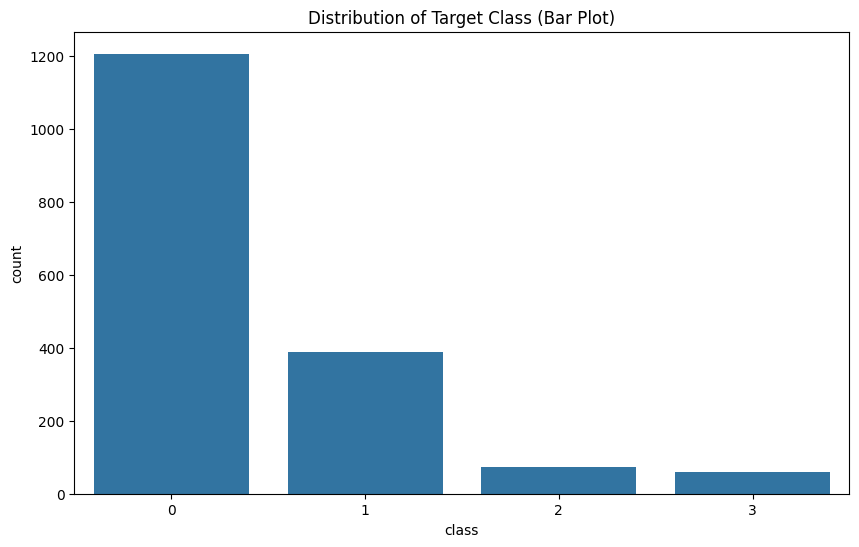

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=df_clean)
plt.title('Distribution of Target Class (Bar Plot)')
plt.show()


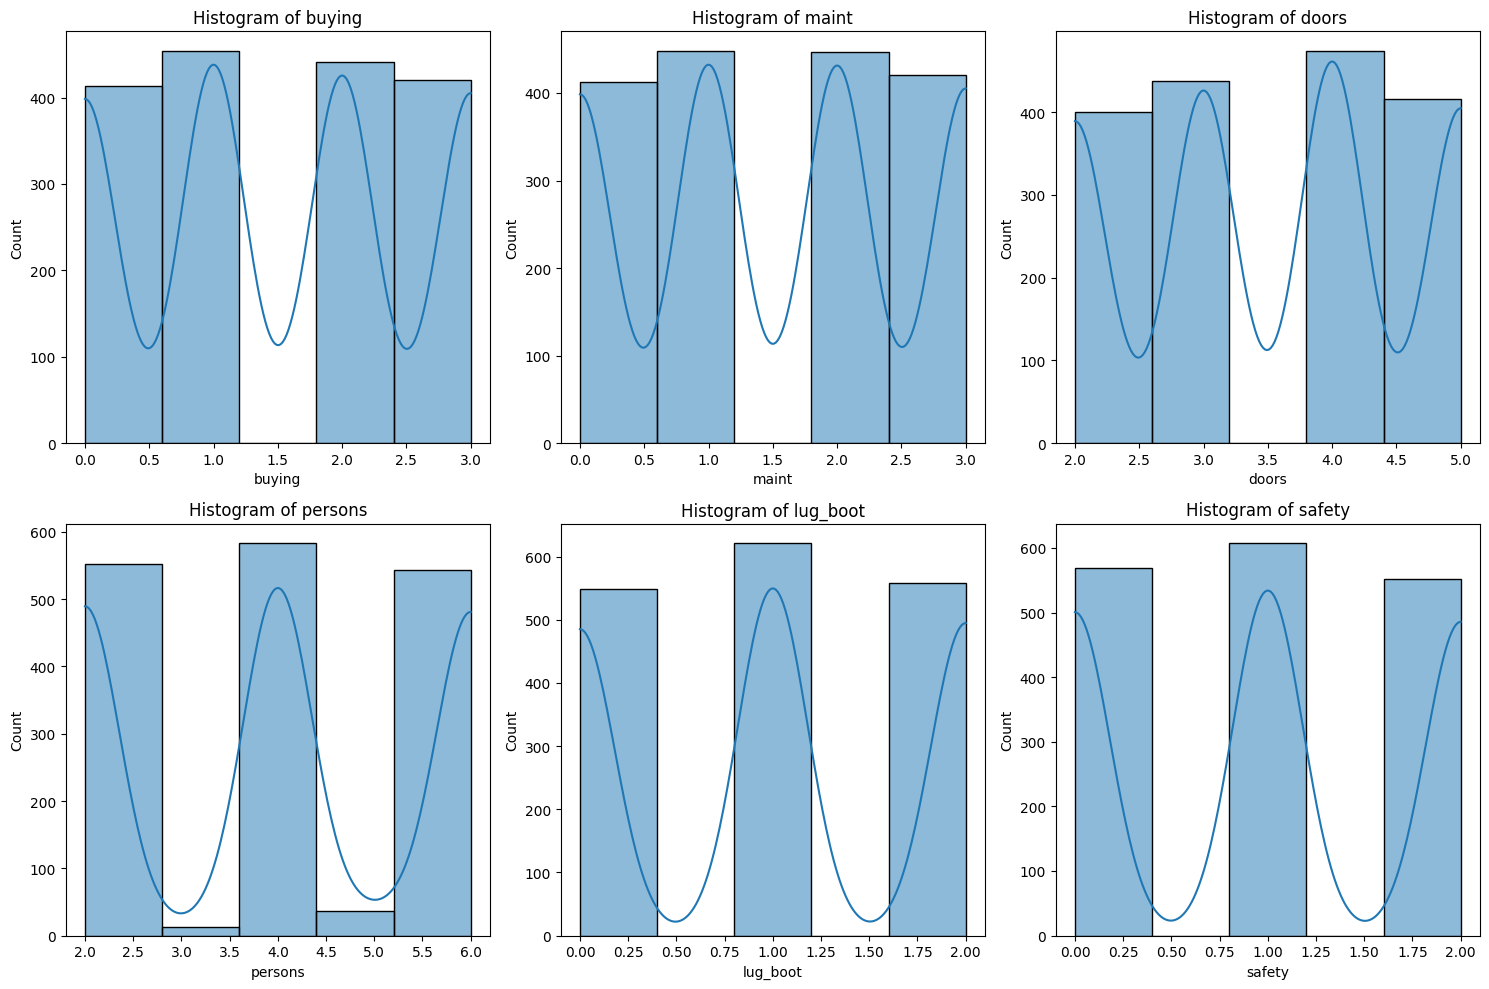

In [10]:
features = X.columns
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_clean[feature], kde=True, bins=5)
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()


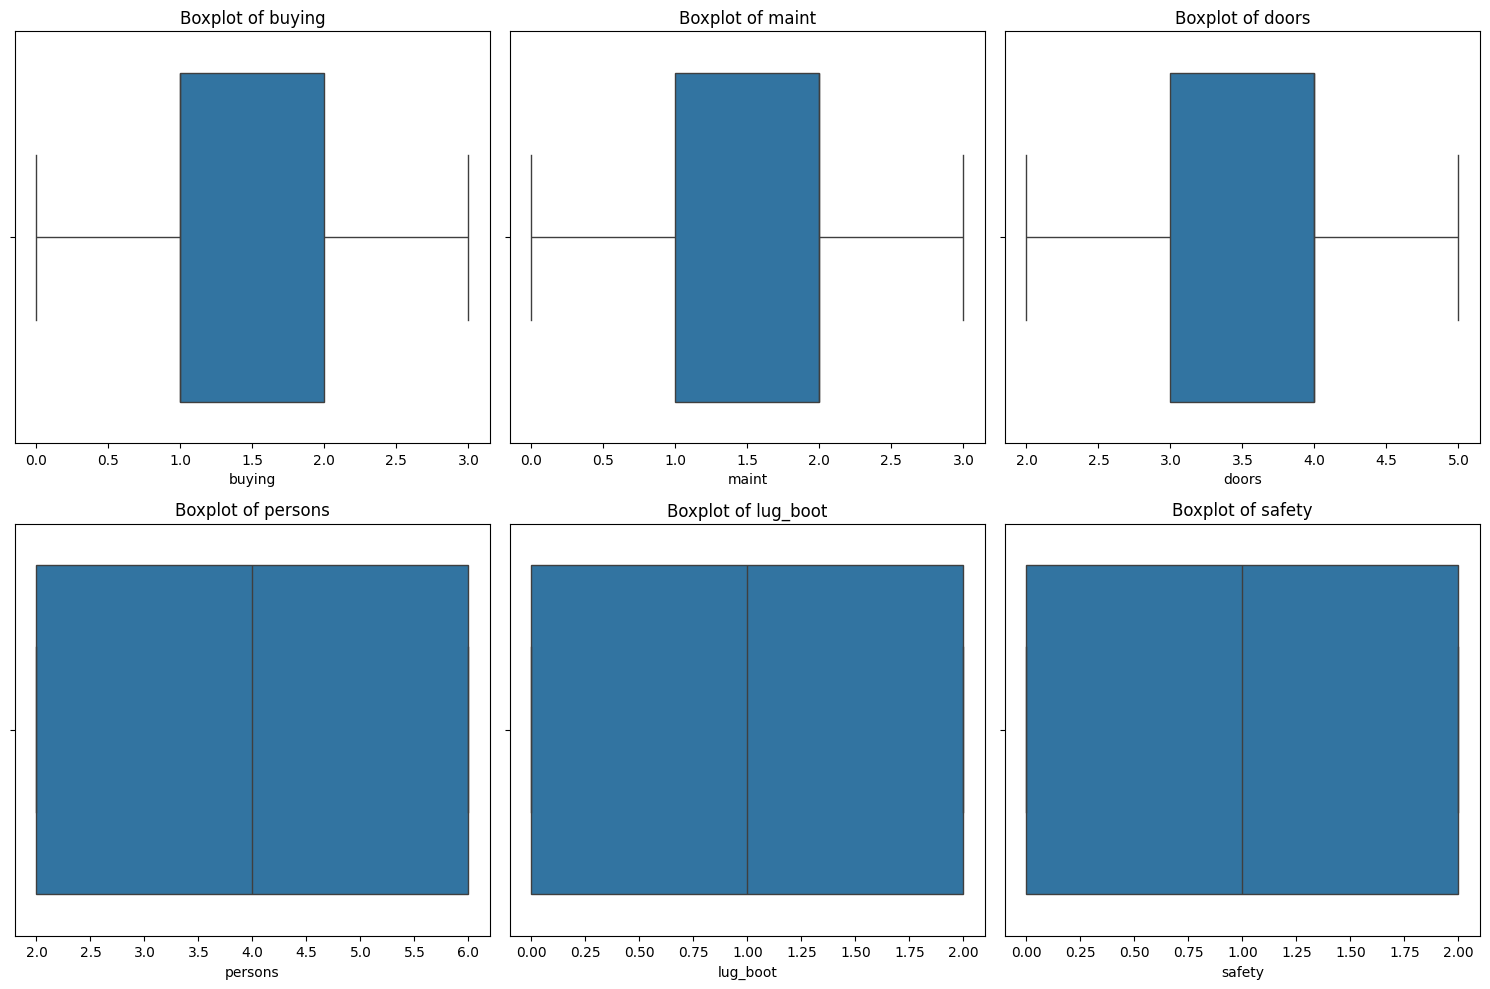

In [11]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_clean[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()


## Module 5: Balancing Dataset
Undersampling, Oversampling, SMOTE. Entropy Analysis.


In [12]:
def calculate_entropy(y):
    elements, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

entropy_original = calculate_entropy(y)
print(f'Entropy of Original (Imbalanced): {entropy_original:.4f}')

# 1. Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_transformed, y)
entropy_under = calculate_entropy(y_under)
print(f'Entropy of Undersampled: {entropy_under:.4f}')

# 2. Oversampling (SMOTE)
# SMOTE works better with numerical/ordinal data, which we have prepared
smote = SMOTE(random_state=42, k_neighbors=2)
X_smote, y_smote = smote.fit_resample(X_transformed, y)
entropy_smote = calculate_entropy(y_smote)
print(f'Entropy of SMOTE Balanced: {entropy_smote:.4f}')


Entropy of Original (Imbalanced): 1.2065
Entropy of Undersampled: 2.0000
Entropy of SMOTE Balanced: 2.0000


## Module 6: Supervised Learning
ID3, Bayes, MLP, Linear Regression.


In [13]:
# Train/Test Split (Using SMOTE data)
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)
models = {}

# a) ID3 Decision Tree (criterion='entropy' mimics Information Gain)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
models['ID3 Decision Tree'] = dt
print('Decision Tree Rules (First 500 chars):')
print(export_text(dt, feature_names=list(X.columns))[:500])

# b) Bayesian Classifier (GaussianNB for continuous inputs from transformation)
nb = GaussianNB()
nb.fit(X_train, y_train)
models['Bayesian Classifier'] = nb

# c) MLP (Backpropagation NN)
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', random_state=42)
mlp.fit(X_train, y_train)
models['MLP Classifier'] = mlp

# d) Linear Regression (Multivariate)
lr = LinearRegression()
lr.fit(X_train, y_train)
models['Linear Regression'] = lr


Decision Tree Rules (First 500 chars):
|--- safety <= 1.18
|   |--- safety <= -0.59
|   |   |--- class: 0
|   |--- safety >  -0.59
|   |   |--- maint <= -0.36
|   |   |   |--- buying <= 0.47
|   |   |   |   |--- persons <= -0.61
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- persons >  -0.61
|   |   |   |   |   |--- lug_boot <= -1.21
|   |   |   |   |   |   |--- persons <= 0.64
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- persons >  0.64
|   |   |   |   |   |   |   |--- doors <= 0.44
|   |   |   |   


## Module 7: Unsupervised Learning
K-Means, SOM, DBSCAN, Mean Shift.


In [14]:
cluster_results = {}

# a) K-Means
kmeans = KMeans(n_clusters=4, random_state=42) # 4 classes
labels_kmeans = kmeans.fit_predict(X_transformed)
cluster_results['KMeans'] = labels_kmeans

# b) SOM Clustering
som = MiniSom(x=10, y=10, input_len=X_transformed.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_transformed.values)
som.train_random(X_transformed.values, 100)
labels_som = [str(som.winner(x)) for x in X_transformed.values]
cluster_results['SOM'] = labels_som

# c) DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_transformed)
cluster_results['DBSCAN'] = labels_dbscan

# d) Mean Shift
meanshift = MeanShift()
labels_meanshift = meanshift.fit_predict(X_transformed)
cluster_results['MeanShift'] = labels_meanshift


## Module 8: Performance Metrics
Sensitivity, Specificity, Accuracy, Precision, Recall, F1, ROC, Silhouette.


In [15]:
for name, model in models.items():
    print(f'--- {name} ---')
    if name == 'Linear Regression':
        y_pred = np.clip(np.round(model.predict(X_test)), 0, 3).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision (Weighted): {prec:.4f}')
    print(f'Recall/Sensitivity (Weighted): {rec:.4f}')
    print(f'F1 Score (Weighted): {f1:.4f}')
    
    # ROC (for multi-class, complex to show, showing AUC if possible)
    if hasattr(model, 'predict_proba'):
        try:
            probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, probs, multi_class='ovr')
            print(f'ROC AUC (OvR): {auc:.4f}')
        except Exception as e:
            print('ROC AUC: N/A')
    
    print('\n')


--- ID3 Decision Tree ---
Accuracy: 0.9700
Precision (Weighted): 0.9702
Recall/Sensitivity (Weighted): 0.9700
F1 Score (Weighted): 0.9701
ROC AUC (OvR): 0.9829


--- Bayesian Classifier ---
Accuracy: 0.6708
Precision (Weighted): 0.7442
Recall/Sensitivity (Weighted): 0.6708
F1 Score (Weighted): 0.6672
ROC AUC (OvR): 0.9106


--- MLP Classifier ---
Accuracy: 0.9834
Precision (Weighted): 0.9835
Recall/Sensitivity (Weighted): 0.9834
F1 Score (Weighted): 0.9834
ROC AUC (OvR): 0.9973


--- Linear Regression ---
Accuracy: 0.6429
Precision (Weighted): 0.7553
Recall/Sensitivity (Weighted): 0.6429
F1 Score (Weighted): 0.6493




In [16]:
print('--- Clustering Silhouette Scores ---')
for name, labels in cluster_results.items():
    try:
        if name == 'SOM':
            pass # Skip string labels for silhouette
        else:
            unique = len(set(labels))
            if 1 < unique < len(X_transformed):
                sil = silhouette_score(X_transformed, labels)
                print(f'{name}: {sil:.4f}')
            else:
                print(f'{name}: Not applicable (single cluster or noise)')
    except Exception as e:
        print(f'{name}: Error ({e})')


--- Clustering Silhouette Scores ---
KMeans: 0.1179
DBSCAN: Not applicable (single cluster or noise)
MeanShift: Not applicable (single cluster or noise)
